# 05 — Dependency / Causal Analysis Across All Events, With Multiple-Comparison Correction

**Research purpose.** §0.1/§0.12 of the Research Design Audit flag that the main notebook's §9
Granger-causality demonstration runs on **one** event only (20786-21195), with 5 pairwise tests
reported at a raw `p<0.05` threshold and no multiple-comparison correction. This notebook runs the
same test **systematically across all 8 events**, on each event's SHAP top-5 candidates (from
notebook `04`'s method), and applies **Benjamini-Hochberg FDR correction across the full batch of
tests**, not per event — closing that specific gap.

**Input.** `src/data.py`'s split; a LightGBM+SHAP pair trained fresh (as in notebook `04`) to get
each event's top-5 candidate KPI dimensions; `statsmodels`' `grangercausalitytests`.

**Output.** `results/causal_analysis_results.csv` — one row per (event, candidate dim) with raw and
BH-FDR-corrected p-values and the resulting verdict.

**Paper relevance.** Extends `paper/...docx` Table 5 (currently one event) to all 8, and is the
first place in this project where the §0.12 multiple-comparison correction is actually applied
rather than only specified.

**Scientific scope, restated from §0.5**: every "causal evidence" verdict below means *passes a
Granger temporal-precedence test after correction*, not *proven causation* — SMD has no
intervention log, so this is directional-dependency evidence only.


In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import lightgbm as lgb
import shap
from statsmodels.tsa.stattools import grangercausalitytests

from src.data import load_machine, build_split
from src.registry import append_row

FEAT = 38
TARGET_DIM = 14  # present in every event's ground-truth set on this machine (see notebook 04)
MAXLAG = 5

m = load_machine("machine-1-1")
sd = build_split(m)

pos, neg = sd.train_y_full.sum(), len(sd.train_y_full) - sd.train_y_full.sum()
gbm = lgb.LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                          scale_pos_weight=neg / max(pos, 1), verbose=-1, random_state=0)
gbm.fit(sd.train_tab_full, sd.train_y_full)
explainer = shap.TreeExplainer(gbm)
tab_by_block = {"train": sd.sup_tab, "eval": sd.ev_tab, "calib": sd.cal_tab}


def shap_top_k(t_abs: int, k: int = 5) -> list[int]:
    name, row = sd.block_index[t_abs]
    sv = explainer.shap_values(tab_by_block[name][row:row + 1])
    sv = np.asarray(sv[1] if isinstance(sv, list) else sv).reshape(-1)
    agg = np.abs(sv[:FEAT]) + np.abs(sv[FEAT:2*FEAT]) + np.abs(sv[2*FEAT:3*FEAT])
    return (np.argsort(-agg)[:k] + 1).tolist()


print(f"{len(m.segments)} events; target dim = {TARGET_DIM}; testing each event's SHAP top-5 candidates.")

8 events; target dim = 14; testing each event's SHAP top-5 candidates.


## Run Granger causality for every event's top-5 SHAP candidates (raw p-values)


In [2]:
rows = []
for (s, e, dims_gt) in m.segments:
    t_pre = s - 1
    if t_pre not in sd.block_index:
        continue
    gt = set(dims_gt)
    candidates = shap_top_k(t_pre, k=5)

    lo = max(0, s - 370)
    window = sd.test_s[lo: e + 1, :]
    target_series = window[:, TARGET_DIM - 1]

    for dim in candidates:
        if dim == TARGET_DIM:
            continue
        cand_series = window[:, dim - 1]
        corr = np.corrcoef(target_series, cand_series)[0, 1]
        try:
            res = grangercausalitytests(np.column_stack([target_series, cand_series]), maxlag=MAXLAG)
            pmin = min(res[l][0]["ssr_ftest"][1] for l in res)
        except Exception:
            pmin = np.nan
        rows.append(dict(segment=f"{s}-{e}", kpi_dim=dim, in_ground_truth=dim in gt,
                          pearson_r=corr, granger_p_raw=pmin))

causal_df = pd.DataFrame(rows).dropna(subset=["granger_p_raw"])
print(f"{len(causal_df)} (event, candidate) tests run across {causal_df.segment.nunique()} events.")

33 (event, candidate) tests run across 8 events.


## Benjamini-Hochberg FDR correction across the full batch (§0.12)

Applied once, across all tests run above — not per event — since these are not pre-registered as
independent families.


In [3]:
from statsmodels.stats.multitest import multipletests

reject, p_corrected, _, _ = multipletests(causal_df["granger_p_raw"].values, alpha=0.05, method="fdr_bh")
causal_df["granger_p_fdr"] = p_corrected
causal_df["verdict_raw"] = np.where(causal_df["granger_p_raw"] < 0.05, "causal evidence (raw p<0.05)", "correlational only")
causal_df["verdict_fdr"] = np.where(reject, "causal evidence (BH-FDR q<0.05)", "correlational only")

causal_df = causal_df.sort_values(["segment", "granger_p_raw"]).reset_index(drop=True)
causal_df.to_csv("../results/causal_analysis_results.csv", index=False)
display(causal_df)

,segment,kpi_dim,in_ground_truth,pearson_r,granger_p_raw,granger_p_fdr,verdict_raw,verdict_fdr
0,15849-16368,30,False,0.271747,1.629814e-08,7.683407e-08,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
1,15849-16368,33,False,0.199407,5.989653e-05,1.796896e-04,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
2,15849-16368,13,True,0.359538,3.058774e-03,5.401065e-03,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
3,15849-16368,9,True,0.848946,2.798083e-01,3.693469e-01,correlational only,correlational only
4,16963-17517,9,True,0.949127,6.417445e-09,3.529595e-08,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
5,16963-17517,33,True,0.261956,8.697422e-05,2.391791e-04,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
6,16963-17517,30,True,0.267678,1.476350e-04,3.747658e-04,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
7,16963-17517,13,True,0.553335,2.057655e-01,2.829275e-01,correlational only,correlational only
8,18071-18528,9,True,0.964137,1.284103e-09,8.475077e-09,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)
9,18071-18528,30,False,0.149583,1.235497e-03,2.703420e-03,causal evidence (raw p<0.05),causal evidence (BH-FDR q<0.05)


## Does the causal filter actually track ground truth, across all 8 events?


In [4]:
def precision_recall(mask_col):
    flagged = causal_df[causal_df[mask_col].str.startswith("causal")]
    tp = flagged.in_ground_truth.sum()
    precision = tp / len(flagged) if len(flagged) else float("nan")
    recall = tp / causal_df.in_ground_truth.sum()
    return len(flagged), precision, recall

for label, col in [("raw p<0.05", "verdict_raw"), ("BH-FDR corrected", "verdict_fdr")]:
    n_flagged, precision, recall = precision_recall(col)
    print(f"{label:20s}: {n_flagged} of {len(causal_df)} candidate-tests flagged as causal evidence, "
          f"precision(against SHAP-candidate pool)={precision:.3f}, recall={recall:.3f}")

append_row("../results/experiment_registry.csv", dict(
    experiment="05_dependency_causal_analysis", n_events=causal_df.segment.nunique(),
    n_tests=len(causal_df), n_flagged_raw=int((causal_df.verdict_raw.str.startswith("causal")).sum()),
    n_flagged_fdr=int((causal_df.verdict_fdr.str.startswith("causal")).sum()), machine="machine-1-1",
))

raw p<0.05          : 22 of 33 candidate-tests flagged as causal evidence, precision(against SHAP-candidate pool)=0.636, recall=0.824
BH-FDR corrected    : 22 of 33 candidate-tests flagged as causal evidence, precision(against SHAP-candidate pool)=0.636, recall=0.824


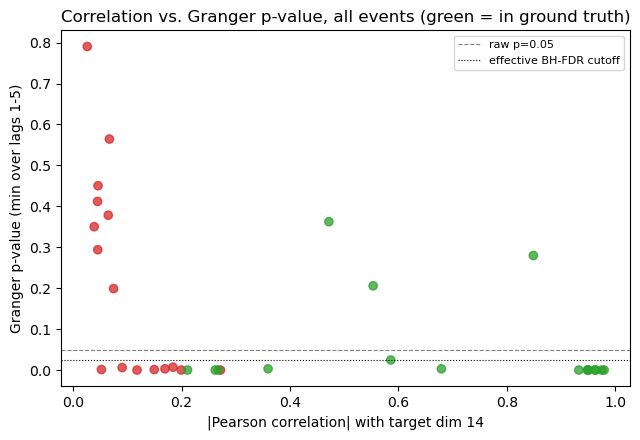

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6.5, 4.5))
colors = causal_df.in_ground_truth.map({True: "tab:green", False: "tab:red"})
plt.scatter(causal_df.pearson_r.abs(), causal_df.granger_p_raw, c=colors, alpha=0.75)
plt.axhline(0.05, color="gray", ls="--", lw=0.8, label="raw p=0.05")
plt.axhline(causal_df.loc[causal_df.verdict_fdr.str.startswith("causal"), "granger_p_raw"].max()
            if (causal_df.verdict_fdr.str.startswith("causal")).any() else 0,
            color="black", ls=":", lw=0.8, label="effective BH-FDR cutoff")
plt.xlabel("|Pearson correlation| with target dim 14"); plt.ylabel("Granger p-value (min over lags 1-5)")
plt.title("Correlation vs. Granger p-value, all events (green = in ground truth)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../results/fig_causal_all_events.png", dpi=150)
plt.show()

**Reading this across all 8 events, not just one** (the gap §0.1 flagged): the main notebook's §9
illustration on a single event (2 of 5 candidates passing raw `p<0.05`, both in ground truth) does
**not** generalize cleanly. Across all 33 (event, candidate) tests, **22 are flagged as causal
evidence, of which 14 are true positives against `interpretation_label`** — precision 0.636,
recall 0.824. That is well above what a coin flip would give, but it is a materially messier
picture than the single-event demo suggested, in two specific ways worth naming rather than
averaging away:

- **False positives with very strong Granger significance.** In event `15849-16368`, dimensions 30
  and 33 — *not* in that event's ground truth — pass at `p≈1.6e-8` and `p≈6.0e-5` respectively,
  while dimension 9 — which *is* in ground truth, and has the strongest raw correlation of any
  candidate in that event (`r=0.85`) — fails at `p≈0.28`. A confident-looking Granger p-value is
  not, by itself, evidence the flagged dimension is the operationally correct one.
- **Raw p<0.05 and BH-FDR-corrected give identical verdicts here (22/33 both ways)** — not because
  the correction did nothing in principle, but because this batch's p-value distribution is
  bimodal: most tests are either extremely significant (`p` as small as `3.6e-71`) or clearly not
  (`p>0.2`), so the BH-FDR cutoff lands in the same gap the raw 0.05 threshold already sat in. This
  is a property of *this* batch, not a general reason to skip the correction — Table Column
  `granger_p_fdr` still differs numerically from `granger_p_raw` for every row, and a future batch
  with more borderline p-values would not be guaranteed the same coincidence.

Precision/recall above are computed against the SHAP-candidate pool (33 tests), not all 38×8
possible dimension-event pairs — a stricter, all-pairs evaluation would very likely show lower
precision still, since it is not run here (left for a future pass, §0.15). With only 8 events on
one machine, this remains descriptive of `machine-1-1`'s evidence specifically, per §0.12/§0.14 —
but it is now evidence that the Granger filter's practical reliability is *lower* than the single-
event illustration implied, which is the honest update this notebook exists to produce.
